In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pr_chain.utils import C
from pr_chain.processing import compute_caf, block_lattice_filter, apply_w
from pr_chain.generators import ClutterGenerator, EchoGenerator


In [3]:
N = 500000  # Number of samples


Np = 200
fs = 8e6
f_c = 700e6
wavelength = C / f_c
N_ch = 1

V_b = np.array([10, 100])  # Target velocity (m/s)

P_transmitter = np.array([0, 0])  # Transmitter position
P_radar = np.array([70, 150])  # Radar position
P_target = np.array([20, 220])  # Target position at time 0


reference_signal = np.random.randn(N) + 1j * np.random.randn(N)  # Complex white Gaussian noise as reference signal
clutter_gen = ClutterGenerator(
        fs = fs,
        N_CLUTT = 20,
        clutter_rcs_min_db=0,
        clutter_rcs_max_db=0,
        clutter_limits = np.array([-10, 500, 5, 150]),
        Tx_position = P_transmitter,
        Rx_position = P_radar
    )
echo_gen = EchoGenerator(
        fs = fs,
        f_c =  f_c,
        V_b = V_b,
        add_noise = False,
        rand_target= False,
        target_rcs_db=-3,
        target_position = P_target,
        Tx_position = P_transmitter,
        Rx_position = P_radar
)
clutter = clutter_gen.generate(reference_signal)
echo, f_D = echo_gen.generate(reference_signal)
surv = echo + clutter

In [4]:
caf, f, r = compute_caf(batch=Np, fs=fs, surveillance= surv, reference= reference_signal)


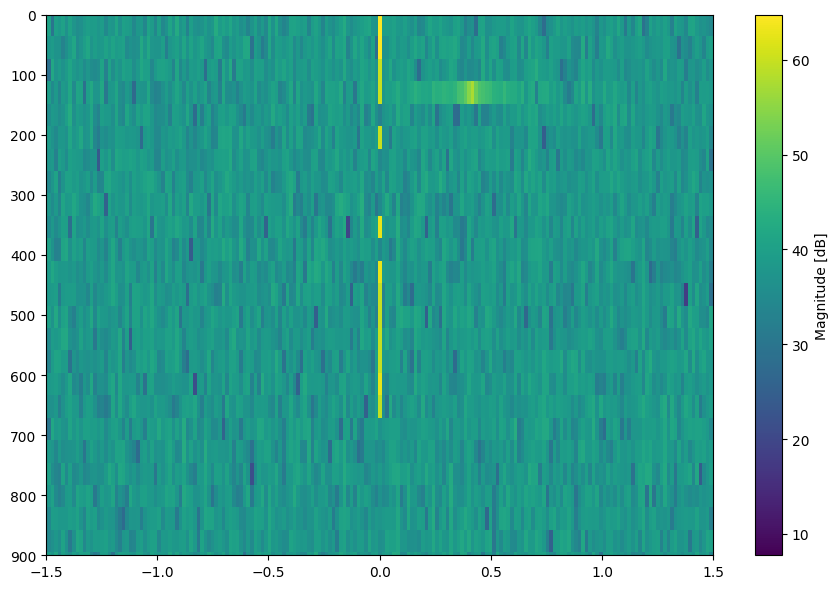

In [5]:
fig4, ax4 = plt.subplots(figsize=(9, 6))
extent = [f[0] / 1e3, f[-1] / 1e3, r[-1], r[0]]
im = ax4.imshow(
    10 * np.log10(np.abs(caf)), cmap="viridis", aspect="auto", extent=extent
)


plt.colorbar(im, ax=ax4, label="Magnitude [dB]")
plt.ylim(900,0)
plt.xlim(-1.5,1.5)
plt.tight_layout()
plt.show()


In [6]:
filtered_surv = block_lattice_filter(surveillance=echo+clutter, reference=reference_signal, order=30)
caf_filtered_w, _, _ = compute_caf(batch=Np, fs=fs, surveillance=filtered_surv, reference=apply_w(reference_signal, beta=14))
caf_filtered, _, _ = compute_caf(
    batch=Np,
    fs=fs,
    surveillance=filtered_surv,
    reference= reference_signal
)

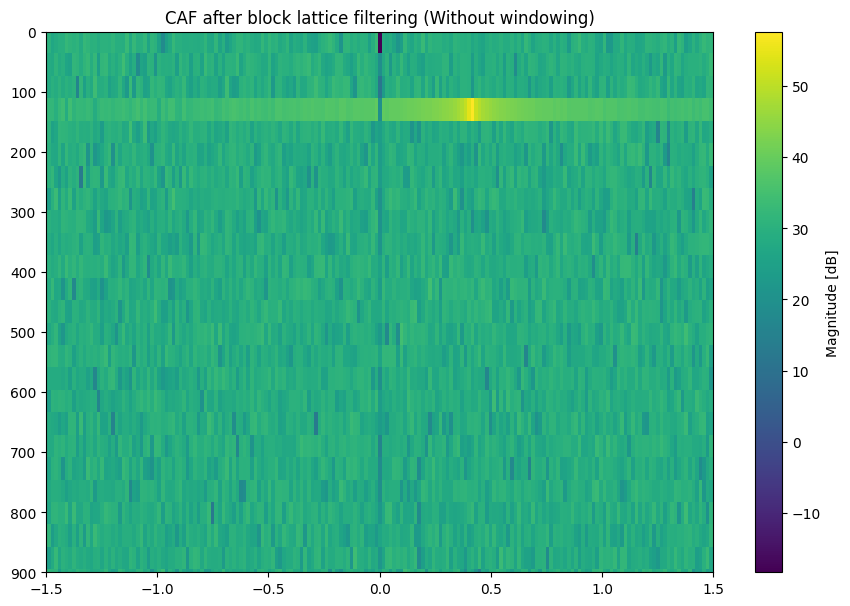

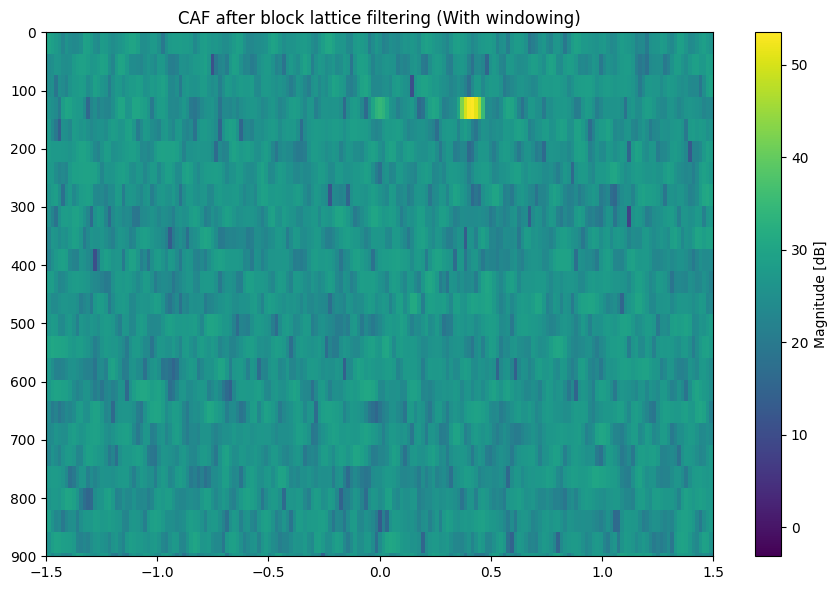

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(
    10 * np.log10(np.abs(caf_filtered)), cmap="viridis", aspect="auto", extent=extent
)


plt.colorbar(im, ax=ax, label="Magnitude [dB]")
plt.ylim(900, 0)
plt.xlim(-1.5, 1.5)
plt.tight_layout()
ax.set_title("CAF after block lattice filtering (Without windowing)")
fig2, ax2 = plt.subplots(figsize=(9, 6))
im = ax2.imshow(
    10 * np.log10(np.abs(caf_filtered_w)), cmap="viridis", aspect="auto", extent=extent
)
ax2.set_title("CAF after block lattice filtering (With windowing)")

plt.colorbar(im, ax=ax2, label="Magnitude [dB]")
plt.ylim(900, 0)
plt.xlim(-1.5, 1.5)
plt.tight_layout()
plt.show()
